In [3]:
pip install gdown 



   -------------------- ------------------- 1/2 [gdown]
   ---------------------------------------- 2/2 [gdown]

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Install these first:
# pip install gdown torch torchaudio

import gdown
import os

# Download HiFi-GAN V1 model
model_url = 'https://drive.google.com/uc?id=1qpgI41wNXFcH-iKq1Y42JlBC9j0je8PW'
output_dir = 'C:/hifi-gan/'
os.makedirs(output_dir, exist_ok=True)

print("Downloading HiFi-GAN model...")
gdown.download(model_url, output_dir + 'generator_v1.pth', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qpgI41wNXFcH-iKq1Y42JlBC9j0je8PW
To: C:\hifi-gan\generator_v1.pth
100%|█████████████████████████████████████████████████████████████████████████████| 55.8M/55.8M [00:12<00:00, 4.30MB/s]


'C:/hifi-gan/generator_v1.pth'

✓ All libraries imported successfully
PyTorch version: 2.2.2+cpu
CUDA available: False
✓ HiFi-GAN model classes defined successfully
✓ Conversion function defined successfully
❌ Directory not found: C:\PC\hifi-gan

Trying alternative path...
✓ Directory found: C:/Users/PC/hifi-gan

Files in directory:
  - .git
  - checkpoints
  - config.json
  - config_v1.json
  - config_v2.json
  - config_v3.json
  - env.py
  - generator_v1.pth
  - g_02500000
  - inference.py
  - inference_e2e.py
  - LICENSE
  - LJSpeech-1.1
  - meldataset.py
  - models.py
  - README.md
  - requirements.txt
  - train.py
  - utils.py
  - validation_loss.png
  - __pycache__

Verifying paths:
Mel file: True - C:\Users\PC\Desktop\CHATGPT-SCRIPT\saved_mels_for_hifigan\sub-02_best_pred.npy
Checkpoint: True - C:/Users/PC/hifi-gan\generator_v1.pth
Config: True - C:/Users/PC/hifi-gan\config_v1.json
Output directory: True

Loading mel spectrogram from: C:\Users\PC\Desktop\CHATGPT-SCRIPT\saved_mels_for_hifigan\sub-02_best_pred.n

C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\utils\weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


✓ Model loaded successfully
Mel spectrogram shape: torch.Size([80, 259])
Input shape to generator: torch.Size([1, 80, 259])
Generating audio...

✓ CONVERSION COMPLETE!
Audio saved to: C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\mels_hifigan\SUB10\mel0_reconstructed.wav
Duration: 3.01 seconds
Sample rate: 22050 Hz
Audio shape: (66304,)

🔊 Playing audio in notebook:


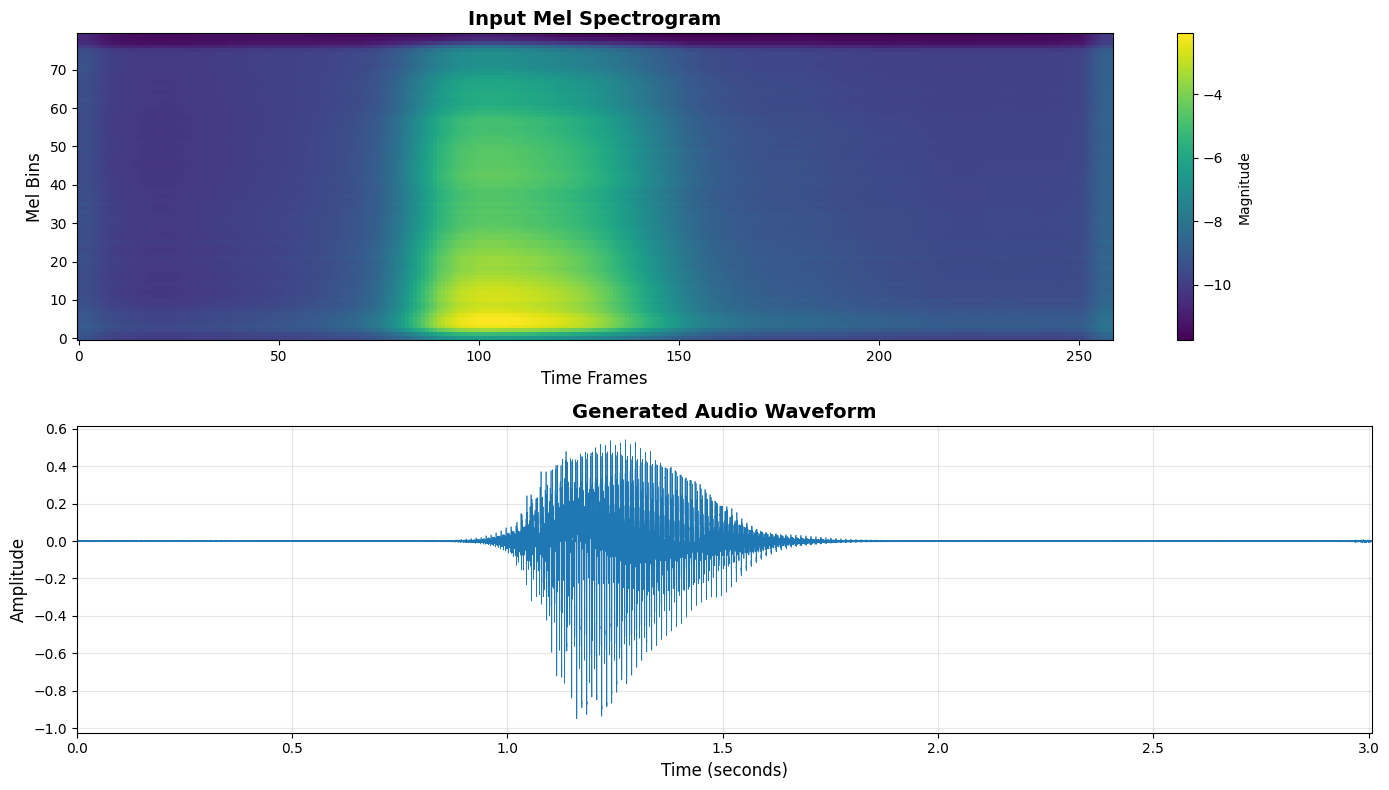


✅ All done! Your audio has been generated successfully!


In [1]:
# ============================================================================
# HiFi-GAN Mel Spectrogram to WAV Converter - Complete Jupyter Notebook
# ============================================================================

# CELL 1: Install required packages (run once)
# Uncomment the line below if you need to install packages
# !pip install torch numpy soundfile scipy matplotlib

# ============================================================================
# CELL 2: Import all required libraries
# ============================================================================
import torch
import numpy as np
import soundfile as sf
import json
import os
import matplotlib.pyplot as plt
from IPython.display import Audio, display

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ============================================================================
# CELL 3: Define HiFi-GAN Model Classes
# ============================================================================

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

class ResBlock(torch.nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=(1, 3, 5)):
        super(ResBlock, self).__init__()
        self.convs1 = torch.nn.ModuleList([
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1, 
                          dilation=dilation[0], padding=self.get_padding(kernel_size, dilation[0]))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=dilation[1], padding=self.get_padding(kernel_size, dilation[1]))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=dilation[2], padding=self.get_padding(kernel_size, dilation[2])))
        ])
        
        self.convs2 = torch.nn.ModuleList([
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1)))
        ])
        
    def get_padding(self, kernel_size, dilation=1):
        return int((kernel_size*dilation - dilation)/2)
    
    def remove_weight_norm(self):
        for l in self.convs1:
            torch.nn.utils.remove_weight_norm(l)
        for l in self.convs2:
            torch.nn.utils.remove_weight_norm(l)
        
    def forward(self, x):
        for c1, c2 in zip(self.convs1, self.convs2):
            xt = torch.nn.functional.leaky_relu(x, 0.1)
            xt = c1(xt)
            xt = torch.nn.functional.leaky_relu(xt, 0.1)
            xt = c2(xt)
            x = xt + x
        return x

class Generator(torch.nn.Module):
    def __init__(self, h):
        super(Generator, self).__init__()
        self.h = h
        self.num_kernels = len(h.resblock_kernel_sizes)
        self.num_upsamples = len(h.upsample_rates)
        self.conv_pre = torch.nn.utils.weight_norm(
            torch.nn.Conv1d(80, h.upsample_initial_channel, 7, 1, padding=3)
        )
        
        self.ups = torch.nn.ModuleList()
        for i, (u, k) in enumerate(zip(h.upsample_rates, h.upsample_kernel_sizes)):
            self.ups.append(torch.nn.utils.weight_norm(
                torch.nn.ConvTranspose1d(
                    h.upsample_initial_channel//(2**i),
                    h.upsample_initial_channel//(2**(i+1)),
                    k, u, padding=(k-u)//2)
            ))
        
        self.resblocks = torch.nn.ModuleList()
        for i in range(len(self.ups)):
            ch = h.upsample_initial_channel//(2**(i+1))
            for k, d in zip(h.resblock_kernel_sizes, h.resblock_dilation_sizes):
                self.resblocks.append(ResBlock(ch, k, d))
        
        self.conv_post = torch.nn.utils.weight_norm(
            torch.nn.Conv1d(ch, 1, 7, 1, padding=3)
        )
        
    def forward(self, x):
        x = self.conv_pre(x)
        for i in range(self.num_upsamples):
            x = torch.nn.functional.leaky_relu(x, 0.1)
            x = self.ups[i](x)
            xs = None
            for j in range(self.num_kernels):
                if xs is None:
                    xs = self.resblocks[i*self.num_kernels+j](x)
                else:
                    xs += self.resblocks[i*self.num_kernels+j](x)
            x = xs / self.num_kernels
        x = torch.nn.functional.leaky_relu(x)
        x = self.conv_post(x)
        x = torch.tanh(x)
        return x
    
    def remove_weight_norm(self):
        try:
            torch.nn.utils.remove_weight_norm(self.conv_pre)
        except:
            pass
        for l in self.ups:
            try:
                torch.nn.utils.remove_weight_norm(l)
            except:
                pass
        for l in self.resblocks:
            l.remove_weight_norm()
        try:
            torch.nn.utils.remove_weight_norm(self.conv_post)
        except:
            pass

print("✓ HiFi-GAN model classes defined successfully")

# ============================================================================
# CELL 4: Define the conversion function
# ============================================================================

def mel_to_wav_hifigan(mel_spectrogram, checkpoint_path, config_path, 
                       output_path='output.wav', sr=22050):
    """
    Convert mel spectrogram to WAV using HiFi-GAN vocoder.
    
    Parameters:
    -----------
    mel_spectrogram : np.ndarray or torch.Tensor
        Mel spectrogram (shape: [n_mels, time])
    checkpoint_path : str
        Path to HiFi-GAN checkpoint file (.pth)
    config_path : str
        Path to config JSON file
    output_path : str
        Output WAV file path
    sr : int
        Sample rate (default: 22050)
    
    Returns:
    --------
    audio : np.ndarray
        Generated audio waveform
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load config
    print(f"Loading config from: {config_path}")
    with open(config_path) as f:
        data = f.read()
    h = AttrDict(json.loads(data))
    print("✓ Config loaded successfully")
    
    # Load model
    print(f"Loading model from: {checkpoint_path}")
    generator = Generator(h).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    generator.eval()
    generator.remove_weight_norm()
    print("✓ Model loaded successfully")
    
    # Prepare input
    if isinstance(mel_spectrogram, np.ndarray):
        mel = torch.FloatTensor(mel_spectrogram).to(device)
    else:
        mel = mel_spectrogram.to(device)
    
    print(f"Mel spectrogram shape: {mel.shape}")
    
    # Add batch dimension if needed
    if mel.dim() == 2:
        mel = mel.unsqueeze(0)
    
    print(f"Input shape to generator: {mel.shape}")
    
    # Generate audio
    print("Generating audio...")
    with torch.no_grad():
        audio = generator(mel)
        audio = audio.squeeze().cpu().numpy()
    
    # Normalize audio
    audio = audio / np.abs(audio).max() * 0.95
    
    # Save WAV file
    sf.write(output_path, audio, sr)
    
    print(f"\n{'='*60}")
    print(f"✓ CONVERSION COMPLETE!")
    print(f"{'='*60}")
    print(f"Audio saved to: {output_path}")
    print(f"Duration: {len(audio)/sr:.2f} seconds")
    print(f"Sample rate: {sr} Hz")
    print(f"Audio shape: {audio.shape}")
    print(f"{'='*60}\n")
    
    return audio

print("✓ Conversion function defined successfully")

# ============================================================================
# CELL 5: Check and set file paths
# ============================================================================

# First, let's find the correct paths
hifi_gan_dir = r'C:\PC\hifi-gan'

# Check if directory exists and list files
if os.path.exists(hifi_gan_dir):
    print(f"✓ Directory found: {hifi_gan_dir}")
    print("\nFiles in directory:")
    for file in os.listdir(hifi_gan_dir):
        print(f"  - {file}")
else:
    print(f"❌ Directory not found: {hifi_gan_dir}")
    print("\nTrying alternative path...")
    hifi_gan_dir = r'C:/Users/PC/hifi-gan'
    if os.path.exists(hifi_gan_dir):
        print(f"✓ Directory found: {hifi_gan_dir}")
        print("\nFiles in directory:")
        for file in os.listdir(hifi_gan_dir):
            print(f"  - {file}")

# Set paths - UPDATE THESE IF NEEDED
mel_path = r'C:\Users\PC\Desktop\CHATGPT-SCRIPT\saved_mels_for_hifigan\sub-02_best_pred.npy'
checkpoint_path = os.path.join(hifi_gan_dir, 'generator_v1.pth')
config_path = os.path.join(hifi_gan_dir, 'config_v1.json')
output_path = r'C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\mels_hifigan\SUB10\mel0_reconstructed.wav'

# Verify all paths exist
print(f"\n{'='*60}")
print("Verifying paths:")
print(f"{'='*60}")
print(f"Mel file: {os.path.exists(mel_path)} - {mel_path}")
print(f"Checkpoint: {os.path.exists(checkpoint_path)} - {checkpoint_path}")
print(f"Config: {os.path.exists(config_path)} - {config_path}")
print(f"Output directory: {os.path.exists(os.path.dirname(output_path))}")
print(f"{'='*60}\n")

# ============================================================================
# CELL 6: Load mel spectrogram
# ============================================================================

print(f"Loading mel spectrogram from: {mel_path}")
mel_spec = np.load(mel_path)

print(f"\n{'='*60}")
print("Mel Spectrogram Information:")
print(f"{'='*60}")
print(f"Shape: {mel_spec.shape}")
print(f"Data type: {mel_spec.dtype}")
print(f"Min value: {mel_spec.min():.4f}")
print(f"Max value: {mel_spec.max():.4f}")
print(f"Mean value: {mel_spec.mean():.4f}")
print(f"{'='*60}\n")

# ============================================================================
# CELL 7: Convert mel to wav
# ============================================================================

audio = mel_to_wav_hifigan(
    mel_spec,
    checkpoint_path=checkpoint_path,
    config_path=config_path,
    output_path=output_path,
    sr=22050  # Change to 16000 or other if your data uses different sample rate
)

# ============================================================================
# CELL 8: Play audio in notebook
# ============================================================================

print("🔊 Playing audio in notebook:")
display(Audio(audio, rate=22050))

# ============================================================================
# CELL 9: Visualize results
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot mel spectrogram
im = axes[0].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Input Mel Spectrogram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Frames', fontsize=12)
axes[0].set_ylabel('Mel Bins', fontsize=12)
plt.colorbar(im, ax=axes[0], label='Magnitude')

# Plot waveform
time = np.arange(len(audio)) / 22050
axes[1].plot(time, audio, linewidth=0.5)
axes[1].set_title('Generated Audio Waveform', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (seconds)', fontsize=12)
axes[1].set_ylabel('Amplitude', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, time[-1]])

plt.tight_layout()
plt.show()

print("\n✅ All done! Your audio has been generated successfully!")

✓ All libraries imported successfully
PyTorch version: 2.2.2+cpu
CUDA available: False
✓ HiFi-GAN model classes defined successfully
✓ Conversion function defined successfully
❌ Directory not found: C:\PC\hifi-gan

Trying alternative path...
✓ Directory found: C:/Users/PC/hifi-gan

Files in directory:
  - .git
  - checkpoints
  - config_v1.json
  - config_v2.json
  - config_v3.json
  - env.py
  - generator_v1.pth
  - g_02500000
  - inference.py
  - inference_e2e.py
  - LICENSE
  - LJSpeech-1.1
  - meldataset.py
  - models.py
  - README.md
  - requirements.txt
  - train.py
  - utils.py
  - validation_loss.png
  - __pycache__

Verifying paths:
Mel file: True - C:/Users/PC/GLOBAL_best_pred.npy
Checkpoint: True - C:/Users/PC/hifi-gan\generator_v1.pth
Config: True - C:/Users/PC/hifi-gan\config_v1.json
Output directory: True

Loading mel spectrogram from: C:/Users/PC/GLOBAL_best_pred.npy

Mel Spectrogram Information:
Shape: (80, 259)
Data type: float32
Min value: -12.1795
Max value: -6.6782


C:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\utils\weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


✓ Model loaded successfully
Mel spectrogram shape: torch.Size([80, 259])
Input shape to generator: torch.Size([1, 80, 259])
Generating audio...

✓ CONVERSION COMPLETE!
Audio saved to: C:/Users/PC/GLOBAL_best_pred.wav
Duration: 3.01 seconds
Sample rate: 22050 Hz
Audio shape: (66304,)

🔊 Playing audio in notebook:


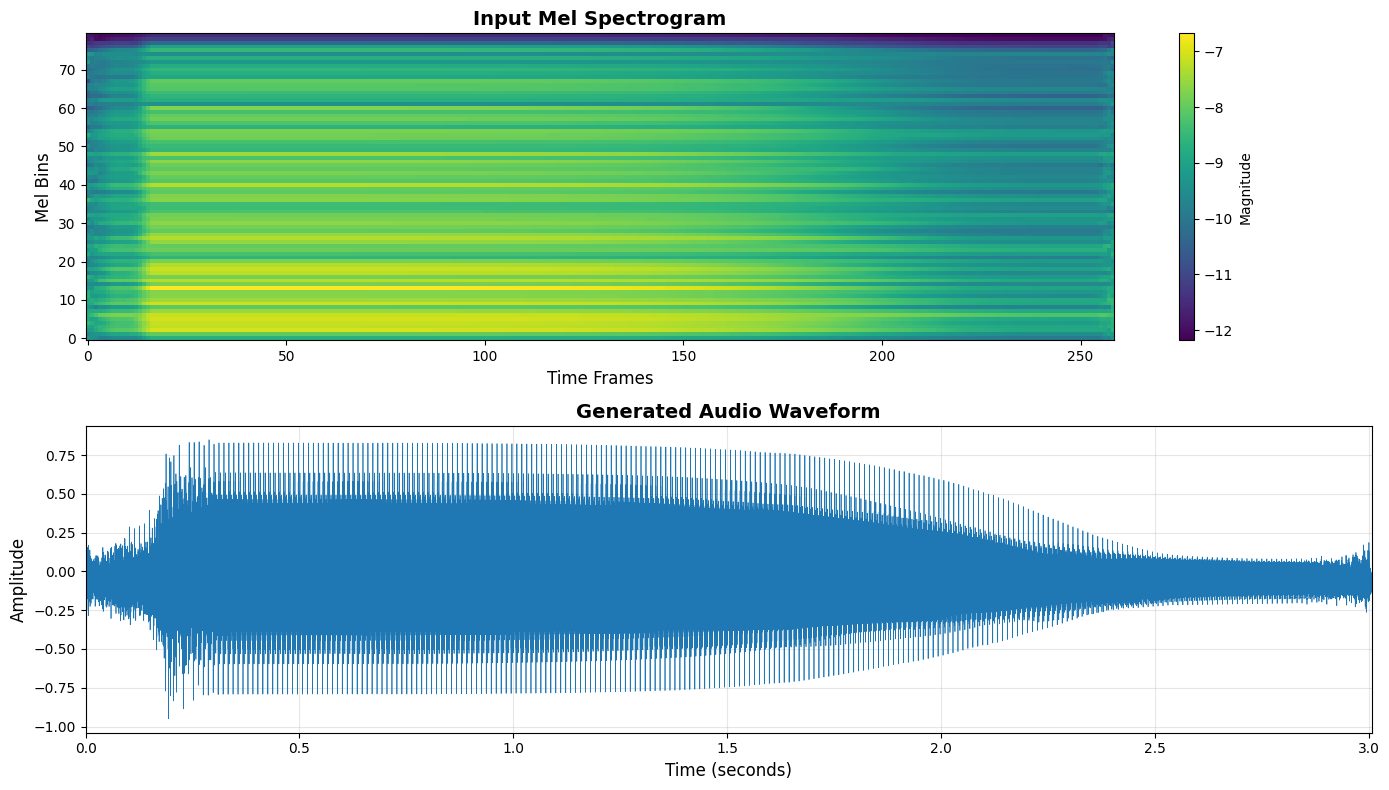


✅ All done! Your audio has been generated successfully!


In [1]:
#C:/Users/PC/Desktop/courses/Conferences/Sevile/test/dataset/pred_mels/SUB1/pred_mel_test0.npy
# ============================================================================
# HiFi-GAN Mel Spectrogram to WAV Converter - Complete Jupyter Notebook
# ============================================================================

# CELL 1: Install required packages (run once)
# Uncomment the line below if you need to install packages
# !pip install torch numpy soundfile scipy matplotlib

# ============================================================================
# CELL 2: Import all required libraries
# ============================================================================
import torch
import numpy as np
import soundfile as sf
import json
import os
import matplotlib.pyplot as plt
from IPython.display import Audio, display

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# ============================================================================
# CELL 3: Define HiFi-GAN Model Classes
# ============================================================================

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

class ResBlock(torch.nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=(1, 3, 5)):
        super(ResBlock, self).__init__()
        self.convs1 = torch.nn.ModuleList([
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1, 
                          dilation=dilation[0], padding=self.get_padding(kernel_size, dilation[0]))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=dilation[1], padding=self.get_padding(kernel_size, dilation[1]))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=dilation[2], padding=self.get_padding(kernel_size, dilation[2])))
        ])
        
        self.convs2 = torch.nn.ModuleList([
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1))),
            torch.nn.utils.weight_norm(torch.nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=self.get_padding(kernel_size, 1)))
        ])
        
    def get_padding(self, kernel_size, dilation=1):
        return int((kernel_size*dilation - dilation)/2)
    
    def remove_weight_norm(self):
        for l in self.convs1:
            torch.nn.utils.remove_weight_norm(l)
        for l in self.convs2:
            torch.nn.utils.remove_weight_norm(l)
        
    def forward(self, x):
        for c1, c2 in zip(self.convs1, self.convs2):
            xt = torch.nn.functional.leaky_relu(x, 0.1)
            xt = c1(xt)
            xt = torch.nn.functional.leaky_relu(xt, 0.1)
            xt = c2(xt)
            x = xt + x
        return x

class Generator(torch.nn.Module):
    def __init__(self, h):
        super(Generator, self).__init__()
        self.h = h
        self.num_kernels = len(h.resblock_kernel_sizes)
        self.num_upsamples = len(h.upsample_rates)
        self.conv_pre = torch.nn.utils.weight_norm(
            torch.nn.Conv1d(80, h.upsample_initial_channel, 7, 1, padding=3)
        )
        
        self.ups = torch.nn.ModuleList()
        for i, (u, k) in enumerate(zip(h.upsample_rates, h.upsample_kernel_sizes)):
            self.ups.append(torch.nn.utils.weight_norm(
                torch.nn.ConvTranspose1d(
                    h.upsample_initial_channel//(2**i),
                    h.upsample_initial_channel//(2**(i+1)),
                    k, u, padding=(k-u)//2)
            ))
        
        self.resblocks = torch.nn.ModuleList()
        for i in range(len(self.ups)):
            ch = h.upsample_initial_channel//(2**(i+1))
            for k, d in zip(h.resblock_kernel_sizes, h.resblock_dilation_sizes):
                self.resblocks.append(ResBlock(ch, k, d))
        
        self.conv_post = torch.nn.utils.weight_norm(
            torch.nn.Conv1d(ch, 1, 7, 1, padding=3)
        )
        
    def forward(self, x):
        x = self.conv_pre(x)
        for i in range(self.num_upsamples):
            x = torch.nn.functional.leaky_relu(x, 0.1)
            x = self.ups[i](x)
            xs = None
            for j in range(self.num_kernels):
                if xs is None:
                    xs = self.resblocks[i*self.num_kernels+j](x)
                else:
                    xs += self.resblocks[i*self.num_kernels+j](x)
            x = xs / self.num_kernels
        x = torch.nn.functional.leaky_relu(x)
        x = self.conv_post(x)
        x = torch.tanh(x)
        return x
    
    def remove_weight_norm(self):
        try:
            torch.nn.utils.remove_weight_norm(self.conv_pre)
        except:
            pass
        for l in self.ups:
            try:
                torch.nn.utils.remove_weight_norm(l)
            except:
                pass
        for l in self.resblocks:
            l.remove_weight_norm()
        try:
            torch.nn.utils.remove_weight_norm(self.conv_post)
        except:
            pass

print("✓ HiFi-GAN model classes defined successfully")

# ============================================================================
# CELL 4: Define the conversion function
# ============================================================================

def mel_to_wav_hifigan(mel_spectrogram, checkpoint_path, config_path, 
                       output_path='output.wav', sr=22050):
    """
    Convert mel spectrogram to WAV using HiFi-GAN vocoder.
    
    Parameters:
    -----------
    mel_spectrogram : np.ndarray or torch.Tensor
        Mel spectrogram (shape: [n_mels, time])
    checkpoint_path : str
        Path to HiFi-GAN checkpoint file (.pth)
    config_path : str
        Path to config JSON file
    output_path : str
        Output WAV file path
    sr : int
        Sample rate (default: 22050)
    
    Returns:
    --------
    audio : np.ndarray
        Generated audio waveform
    """
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load config
    print(f"Loading config from: {config_path}")
    with open(config_path) as f:
        data = f.read()
    h = AttrDict(json.loads(data))
    print("✓ Config loaded successfully")
    
    # Load model
    print(f"Loading model from: {checkpoint_path}")
    generator = Generator(h).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    generator.eval()
    generator.remove_weight_norm()
    print("✓ Model loaded successfully")
    
    # Prepare input
    if isinstance(mel_spectrogram, np.ndarray):
        mel = torch.FloatTensor(mel_spectrogram).to(device)
    else:
        mel = mel_spectrogram.to(device)
    
    print(f"Mel spectrogram shape: {mel.shape}")
    
    # Add batch dimension if needed
    if mel.dim() == 2:
        mel = mel.unsqueeze(0)
    
    print(f"Input shape to generator: {mel.shape}")
    
    # Generate audio
    print("Generating audio...")
    with torch.no_grad():
        audio = generator(mel)
        audio = audio.squeeze().cpu().numpy()
    
    # Normalize audio
    audio = audio / np.abs(audio).max() * 0.95
    
    # Save WAV file
    sf.write(output_path, audio, sr)
    
    print(f"\n{'='*60}")
    print(f"✓ CONVERSION COMPLETE!")
    print(f"{'='*60}")
    print(f"Audio saved to: {output_path}")
    print(f"Duration: {len(audio)/sr:.2f} seconds")
    print(f"Sample rate: {sr} Hz")
    print(f"Audio shape: {audio.shape}")
    print(f"{'='*60}\n")
    
    return audio

print("✓ Conversion function defined successfully")

# ============================================================================
# CELL 5: Check and set file paths
# ============================================================================

# First, let's find the correct paths
hifi_gan_dir = r'C:\PC\hifi-gan'

# Check if directory exists and list files
if os.path.exists(hifi_gan_dir):
    print(f"✓ Directory found: {hifi_gan_dir}")
    print("\nFiles in directory:")
    for file in os.listdir(hifi_gan_dir):
        print(f"  - {file}")
else:
    print(f"❌ Directory not found: {hifi_gan_dir}")
    print("\nTrying alternative path...")
    hifi_gan_dir = r'C:/Users/PC/hifi-gan'
    if os.path.exists(hifi_gan_dir):
        print(f"✓ Directory found: {hifi_gan_dir}")
        print("\nFiles in directory:")
        for file in os.listdir(hifi_gan_dir):
            print(f"  - {file}")

# Set paths - UPDATE THESE IF NEEDED
mel_path = r'C:/Users/PC/GLOBAL_best_pred.npy'
checkpoint_path = os.path.join(hifi_gan_dir, 'generator_v1.pth')
config_path = os.path.join(hifi_gan_dir, 'config_v1.json')
output_path = r'C:/Users/PC/GLOBAL_best_pred.wav'

# Verify all paths exist
print(f"\n{'='*60}")
print("Verifying paths:")
print(f"{'='*60}")
print(f"Mel file: {os.path.exists(mel_path)} - {mel_path}")
print(f"Checkpoint: {os.path.exists(checkpoint_path)} - {checkpoint_path}")
print(f"Config: {os.path.exists(config_path)} - {config_path}")
print(f"Output directory: {os.path.exists(os.path.dirname(output_path))}")
print(f"{'='*60}\n")

# ============================================================================
# CELL 6: Load mel spectrogram
# ============================================================================

print(f"Loading mel spectrogram from: {mel_path}")
mel_spec = np.load(mel_path)

print(f"\n{'='*60}")
print("Mel Spectrogram Information:")
print(f"{'='*60}")
print(f"Shape: {mel_spec.shape}")
print(f"Data type: {mel_spec.dtype}")
print(f"Min value: {mel_spec.min():.4f}")
print(f"Max value: {mel_spec.max():.4f}")
print(f"Mean value: {mel_spec.mean():.4f}")
print(f"{'='*60}\n")

# ============================================================================
# CELL 7: Convert mel to wav
# ============================================================================

audio = mel_to_wav_hifigan(
    mel_spec,
    checkpoint_path=checkpoint_path,
    config_path=config_path,
    output_path=output_path,
    sr=22050  # Change to 16000 or other if your data uses different sample rate
)

# ============================================================================
# CELL 8: Play audio in notebook
# ============================================================================

print("🔊 Playing audio in notebook:")
display(Audio(audio, rate=22050))

# ============================================================================
# CELL 9: Visualize results
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot mel spectrogram
im = axes[0].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Input Mel Spectrogram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Frames', fontsize=12)
axes[0].set_ylabel('Mel Bins', fontsize=12)
plt.colorbar(im, ax=axes[0], label='Magnitude')

# Plot waveform
time = np.arange(len(audio)) / 22050
axes[1].plot(time, audio, linewidth=0.5)
axes[1].set_title('Generated Audio Waveform', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (seconds)', fontsize=12)
axes[1].set_ylabel('Amplitude', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, time[-1]])

plt.tight_layout()
plt.show()

print("\n✅ All done! Your audio has been generated successfully!")


In [9]:
#test version
import scipy
print(scipy.__version__)

      

1.12.0


In [26]:
#(true / pred / pred_energy_matche)
import numpy as np
import os
from IPython.display import Audio, display

# 1) Paths (عدلّي حسب مجلدك)
true_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\true_mel_test0.npy"
pred_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\pred_mel_test0.npy"
pred_em_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\pred_mel_test0_ENERGY_MATCH.npy"

# 2) HiFi-GAN paths
hifi_gan_dir = r"C:/Users/PC/hifi-gan"
ckpt_path = os.path.join(hifi_gan_dir, "generator_v1.pth")
cfg_path  = os.path.join(hifi_gan_dir, "config_v1.json")

# 3) Load mels
true_mel = np.load(true_path)
pred_mel = np.load(pred_path)
pred_em_mel = np.load(pred_em_path)

print("TRUE mel:", true_mel.shape, true_mel.min(), true_mel.max(), float(true_mel.mean()), float(true_mel.std()))
print("PRED mel:", pred_mel.shape, pred_mel.min(), pred_mel.max(), float(pred_mel.mean()), float(pred_mel.std()))
print("PRED+EM mel:", pred_em_mel.shape, pred_em_mel.min(), pred_em_mel.max(), float(pred_em_mel.mean()), float(pred_em_mel.std()))

# 4) Use your existing function mel_to_wav_hifigan
# (هي نفسها اللي عندك واشتغلت ✅)

wav_true = mel_to_wav_hifigan(true_mel, ckpt_path, cfg_path, output_path="true.wav", sr=22050)
wav_pred = mel_to_wav_hifigan(pred_mel, ckpt_path, cfg_path, output_path="pred.wav", sr=22050)
wav_pred_em = mel_to_wav_hifigan(pred_em_mel, ckpt_path, cfg_path, output_path="pred_energy_match.wav", sr=22050)

print("\n🔊 TRUE")
display(Audio(wav_true, rate=22050))
print("\n🔊 PRED (raw)")
display(Audio(wav_pred, rate=22050))
print("\n🔊 PRED (energy-matched)")
display(Audio(wav_pred_em, rate=22050))


TRUE mel: (80, 259) -11.512925 0.69409704 -8.722371101379395 1.9957687854766846
PRED mel: (80, 259) -11.5201235 -6.485329 -8.626094818115234 0.664929211139679
PRED+EM mel: (80, 259) -14.039634 6.3397903 -8.722371101379395 1.8171626329421997
Using device: cpu
Loading config from: C:/Users/PC/hifi-gan\config_v1.json
✓ Config loaded successfully
Loading model from: C:/Users/PC/hifi-gan\generator_v1.pth
✓ Model loaded successfully
Mel spectrogram shape: torch.Size([80, 259])
Input shape to generator: torch.Size([1, 80, 259])
Generating audio...

✓ CONVERSION COMPLETE!
Audio saved to: true.wav
Duration: 3.01 seconds
Sample rate: 22050 Hz
Audio shape: (66304,)

Using device: cpu
Loading config from: C:/Users/PC/hifi-gan\config_v1.json
✓ Config loaded successfully
Loading model from: C:/Users/PC/hifi-gan\generator_v1.pth
✓ Model loaded successfully
Mel spectrogram shape: torch.Size([80, 259])
Input shape to generator: torch.Size([1, 80, 259])
Generating audio...

✓ CONVERSION COMPLETE!
Audio 


🔊 PRED (raw)



🔊 PRED (energy-matched)


TRUE energy mean/std: -8.722371 1.6866391
PRED energy mean/std: -8.626094 0.091031805


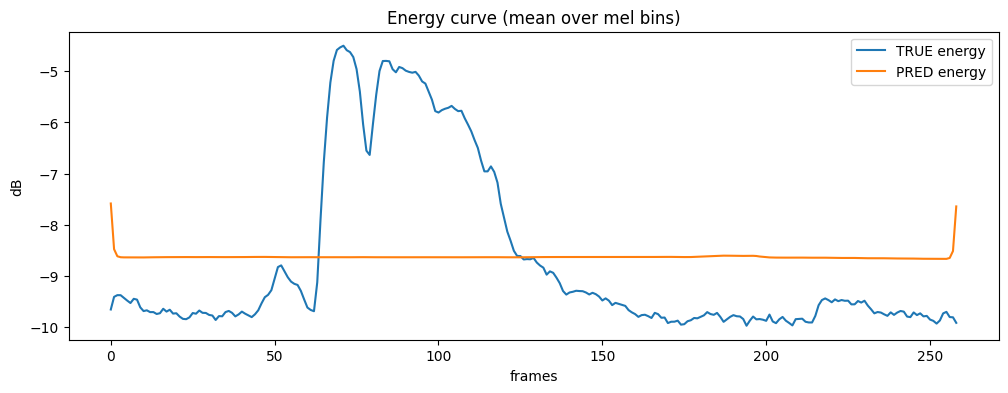

In [23]:
import numpy as np
import matplotlib.pyplot as plt

true_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\true_mel_test0.npy"
pred_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\pred_mel_test0.npy"

true_mel = np.load(true_path)   # (80,T)
pred_mel = np.load(pred_path)

true_energy = true_mel.mean(axis=0)   # (T,)
pred_energy = pred_mel.mean(axis=0)

print("TRUE energy mean/std:", true_energy.mean(), true_energy.std())
print("PRED energy mean/std:", pred_energy.mean(), pred_energy.std())

plt.figure(figsize=(12,4))
plt.plot(true_energy, label="TRUE energy")
plt.plot(pred_energy, label="PRED energy")
plt.legend(); plt.title("Energy curve (mean over mel bins)"); plt.xlabel("frames"); plt.ylabel("dB")
plt.show()


TRUE mel: (80, 259) -11.512925 0.69409704 -8.722371101379395 1.9957687854766846
PRED mel: (80, 259) -11.5201235 -6.485329 -8.626094818115234 0.664929211139679
TRUE frame-energy mean/std: -8.722371101379395 1.6866390705108643
PRED frame-energy mean/std: -8.626093864440918 0.09103180468082428


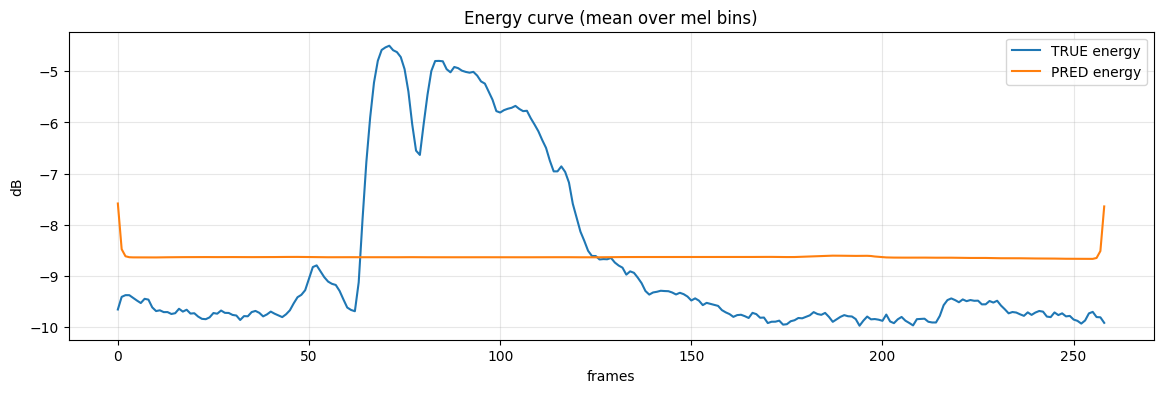

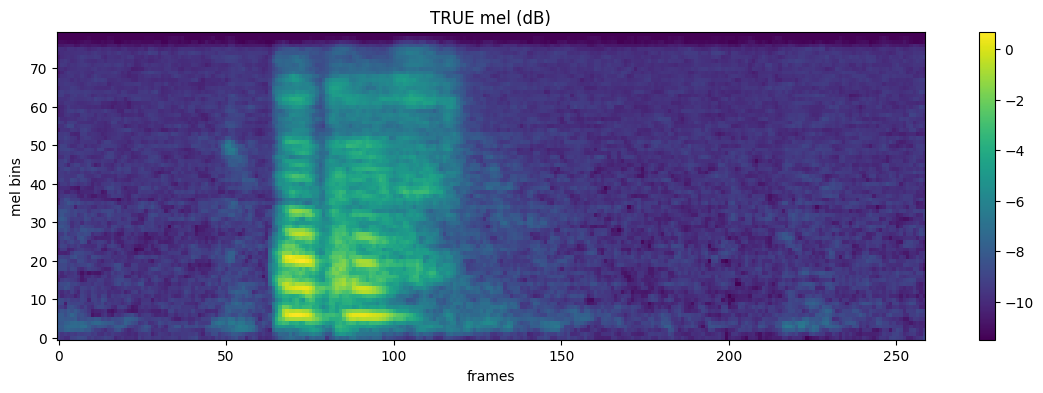

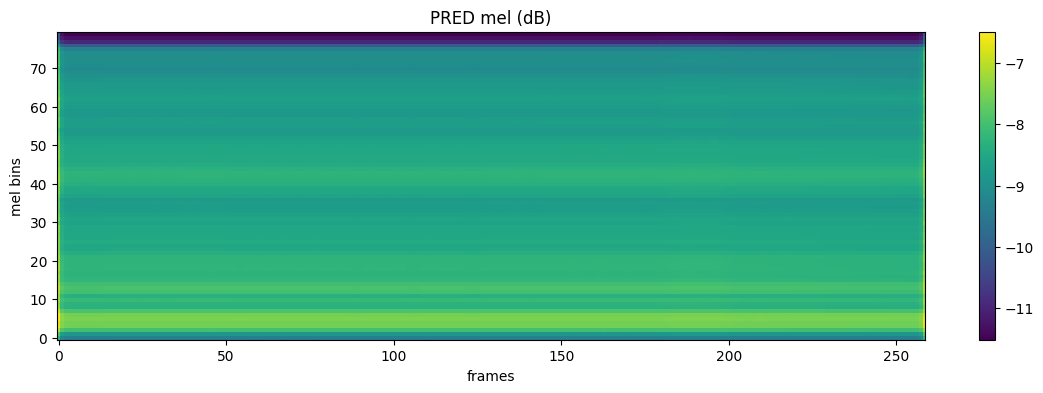

In [25]:
import numpy as np
import matplotlib.pyplot as plt

true_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\true_mel_test0.npy"
pred_path = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\pred_mels\SUB1\pred_mel_test0.npy"

true_mel = np.load(true_path).astype(np.float32)   # (80, T)
pred_mel = np.load(pred_path).astype(np.float32)   # (80, T)

print("TRUE mel:", true_mel.shape, true_mel.min(), true_mel.max(), float(true_mel.mean()), float(true_mel.std()))
print("PRED mel:", pred_mel.shape, pred_mel.min(), pred_mel.max(), float(pred_mel.mean()), float(pred_mel.std()))

true_energy = true_mel.mean(axis=0)   # (T,)
pred_energy = pred_mel.mean(axis=0)   # (T,)

print("TRUE frame-energy mean/std:", float(true_energy.mean()), float(true_energy.std()))
print("PRED frame-energy mean/std:", float(pred_energy.mean()), float(pred_energy.std()))

plt.figure(figsize=(14,4))
plt.plot(true_energy, label="TRUE energy")
plt.plot(pred_energy, label="PRED energy")
plt.title("Energy curve (mean over mel bins)")
plt.xlabel("frames"); plt.ylabel("dB")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14,4))
plt.imshow(true_mel, aspect="auto", origin="lower")
plt.title("TRUE mel (dB)"); plt.xlabel("frames"); plt.ylabel("mel bins")
plt.colorbar(); plt.show()

plt.figure(figsize=(14,4))
plt.imshow(pred_mel, aspect="auto", origin="lower")
plt.title("PRED mel (dB)"); plt.xlabel("frames"); plt.ylabel("mel bins")
plt.colorbar(); plt.show()
